# Graficos para apresentacao

Este notebook concentra graficos simples da analise do projeto.


In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt


## Base e periodos

Carreguei a base e classifiquei os periodos da pandemia para manter os graficos consistentes com a analise.


In [2]:
caminho_arquivo = Path("../data/dados_anonimizados_2026.xlsx")
df_original = pd.read_excel(caminho_arquivo)
df = df_original.copy()

def classificar_periodo(ano):
    if ano <= 2019:
        return "Pré pandemia"
    elif ano <= 2021:
        return "Durante pandemia"
    else:
        return "Pós pandemia"

df["periodo_pandemia"] = df["ano"].apply(classificar_periodo)

df.head()


,ano,mes,cidade_agrupada,class_segmentos,abertura_empresas,periodo_pandemia
0,2018,1,PORTO ALEGRE,Fisioterapia,1,Pré pandemia
1,2018,1,grande_sp,Turismo,11,Pré pandemia
2,2018,1,PORTO ALEGRE,Intermediação,4,Pré pandemia
3,2018,1,CURITIBA,Eventos,5,Pré pandemia
4,2018,1,grande_sp,Fisioterapia,6,Pré pandemia


## Serie historica mensal

Este grafico mostra a evolucao mensal do mercado total. Ele ajuda a ver tendencia, picos e quedas ao longo do tempo.


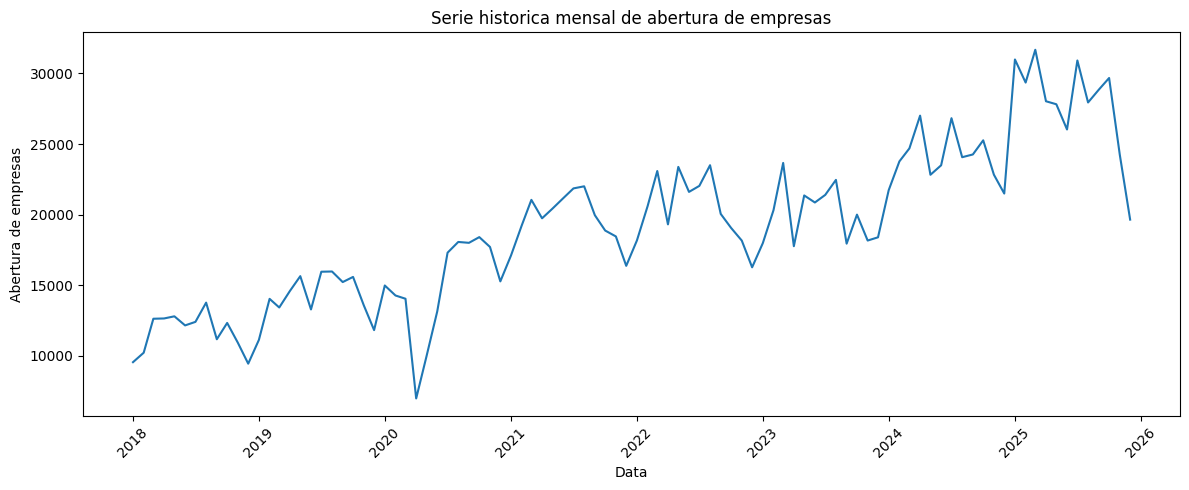

In [3]:
serie_historica_mensal = (
df
.groupby(["ano", "mes"], as_index = False)["abertura_empresas"]
.sum()
)

serie_historica_mensal["data"] = pd.to_datetime(
    serie_historica_mensal["ano"].astype(str) + "-" +
    serie_historica_mensal["mes"].astype(str) + "-01"
)

serie_historica_mensal = serie_historica_mensal.sort_values("data")

plt.figure(figsize = (12, 5))
plt.plot(serie_historica_mensal["data"], serie_historica_mensal["abertura_empresas"])
plt.title("Serie historica mensal de abertura de empresas")
plt.xlabel("Data")
plt.ylabel("Abertura de empresas")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()


## Sazonalidade mensal

Aqui comparo a media por mes do ano para identificar meses que costumam ter maior ou menor volume de aberturas.


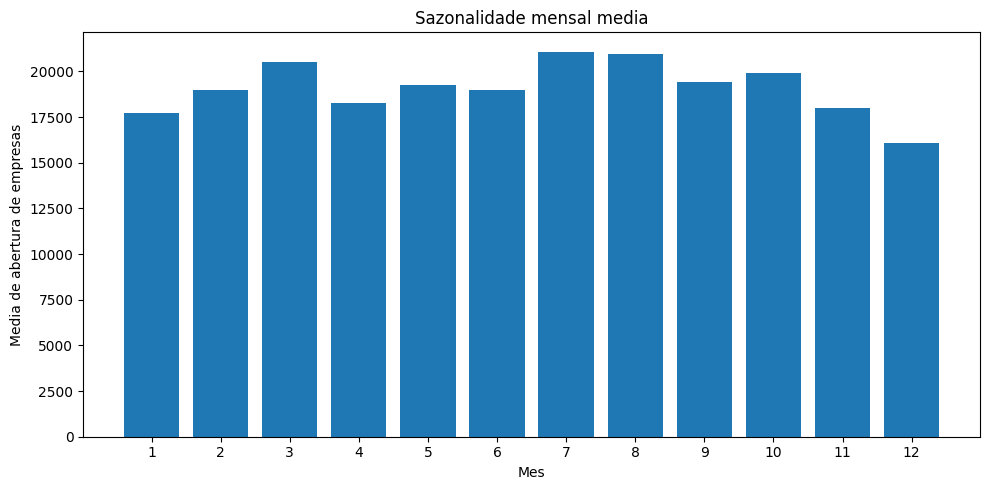

In [4]:
sazonalidade_mensal = (
serie_historica_mensal
.groupby("mes", as_index = False)["abertura_empresas"]
.mean()
.rename(columns = {"abertura_empresas" : "media_mensal_aberturas"})
.sort_values("mes")
)

plt.figure(figsize = (10, 5))
plt.bar(sazonalidade_mensal["mes"], sazonalidade_mensal["media_mensal_aberturas"])
plt.title("Sazonalidade mensal media")
plt.xlabel("Mes")
plt.ylabel("Media de abertura de empresas")
plt.xticks(sazonalidade_mensal["mes"])
plt.tight_layout()
plt.show()


## Media por periodo

Este grafico resume a media mensal antes, durante e depois da pandemia. A intencao e mostrar se o patamar do mercado mudou.


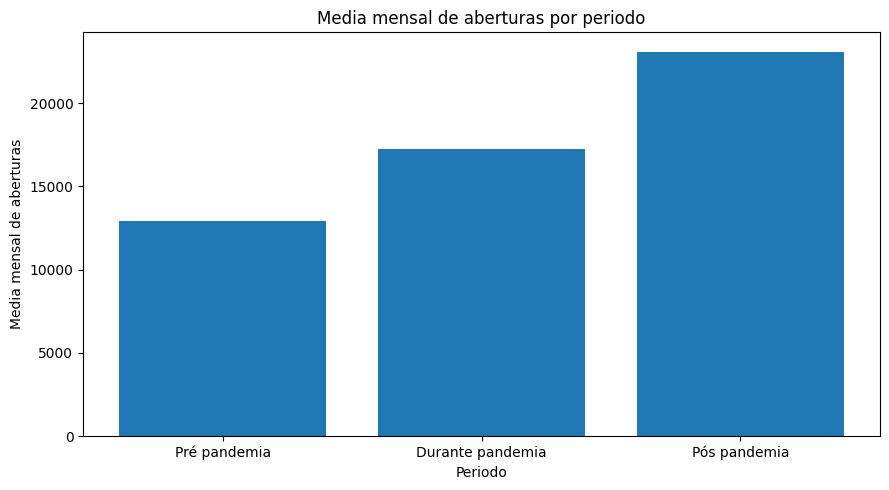

In [5]:
abertura_mensal_periodo = (
df
.groupby(["ano", "mes", "periodo_pandemia"], as_index = False)["abertura_empresas"]
.sum()
)

media_abertura_mensal_periodo = (
abertura_mensal_periodo
.groupby("periodo_pandemia", as_index = False)["abertura_empresas"]
.mean()
.rename(columns = {"abertura_empresas" : "media_mensal_aberturas"})
)

periodo_pre = df[df["ano"] <= 2019]["periodo_pandemia"].iloc[0]
periodo_durante = df[(df["ano"] >= 2020) & (df["ano"] <= 2021)]["periodo_pandemia"].iloc[0]
periodo_pos = df[df["ano"] >= 2022]["periodo_pandemia"].iloc[0]
ordem_periodos = [periodo_pre, periodo_durante, periodo_pos]

media_abertura_mensal_periodo["periodo_pandemia"] = pd.Categorical(
    media_abertura_mensal_periodo["periodo_pandemia"],
    categories = ordem_periodos,
    ordered = True
)
media_abertura_mensal_periodo = media_abertura_mensal_periodo.sort_values("periodo_pandemia")

plt.figure(figsize = (9, 5))
plt.bar(media_abertura_mensal_periodo["periodo_pandemia"], media_abertura_mensal_periodo["media_mensal_aberturas"])
plt.title("Media mensal de aberturas por periodo")
plt.xlabel("Periodo")
plt.ylabel("Media mensal de aberturas")
plt.tight_layout()
plt.show()


## Segmentos por periodo

Comparei os principais segmentos entre periodos para ver quais grupos ganharam mais relevancia no historico.


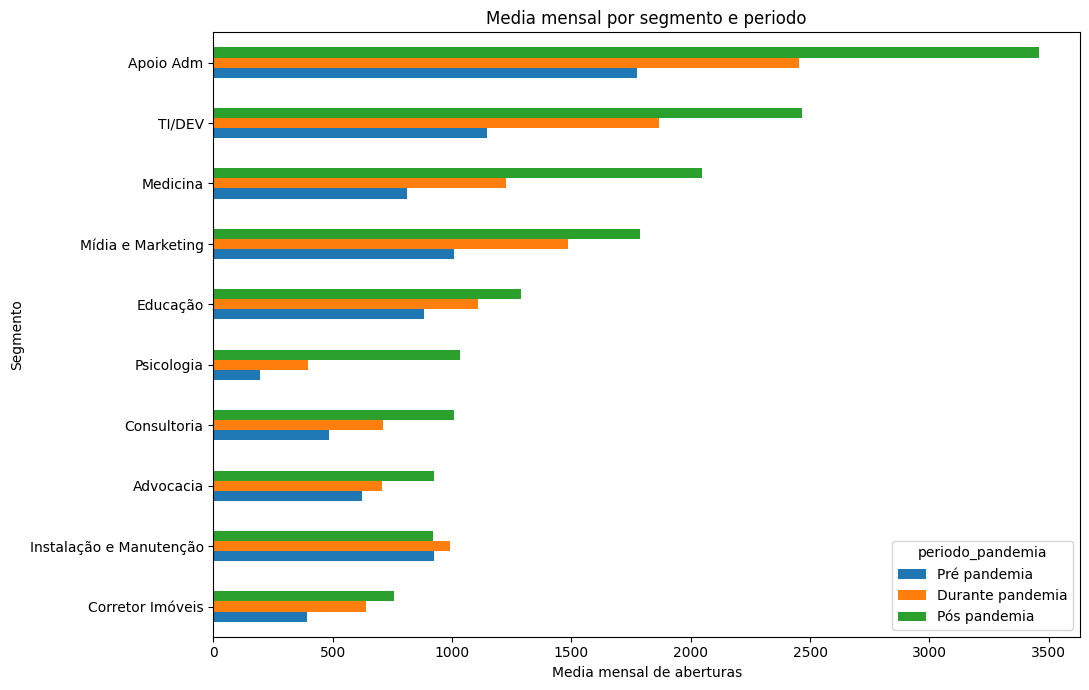

In [6]:
segmentos_mensal_periodo = (
df
.groupby(["class_segmentos", "ano", "mes", "periodo_pandemia"], as_index = False)["abertura_empresas"]
.sum()
)

media_segmentos_periodo = (
segmentos_mensal_periodo
.groupby(["class_segmentos", "periodo_pandemia"], as_index = False)["abertura_empresas"]
.mean()
.rename(columns = {"abertura_empresas" : "media_mensal_aberturas"})
)

principais_segmentos = (
df
.groupby("class_segmentos", as_index = False)["abertura_empresas"]
.sum()
.sort_values("abertura_empresas", ascending = False)
.head(10)["class_segmentos"]
)

grafico_segmentos_periodo = (
media_segmentos_periodo[media_segmentos_periodo["class_segmentos"].isin(principais_segmentos)]
.pivot(index = "class_segmentos", columns = "periodo_pandemia", values = "media_mensal_aberturas")
.fillna(0)
)

grafico_segmentos_periodo = grafico_segmentos_periodo[ordem_periodos]
grafico_segmentos_periodo = grafico_segmentos_periodo.sort_values(periodo_pos)

grafico_segmentos_periodo.plot(kind = "barh", figsize = (11, 7))
plt.title("Media mensal por segmento e periodo")
plt.xlabel("Media mensal de aberturas")
plt.ylabel("Segmento")
plt.tight_layout()
plt.show()


## Cidades por periodo

Este grafico mostra como as cidades agrupadas se comportaram em cada periodo da pandemia.


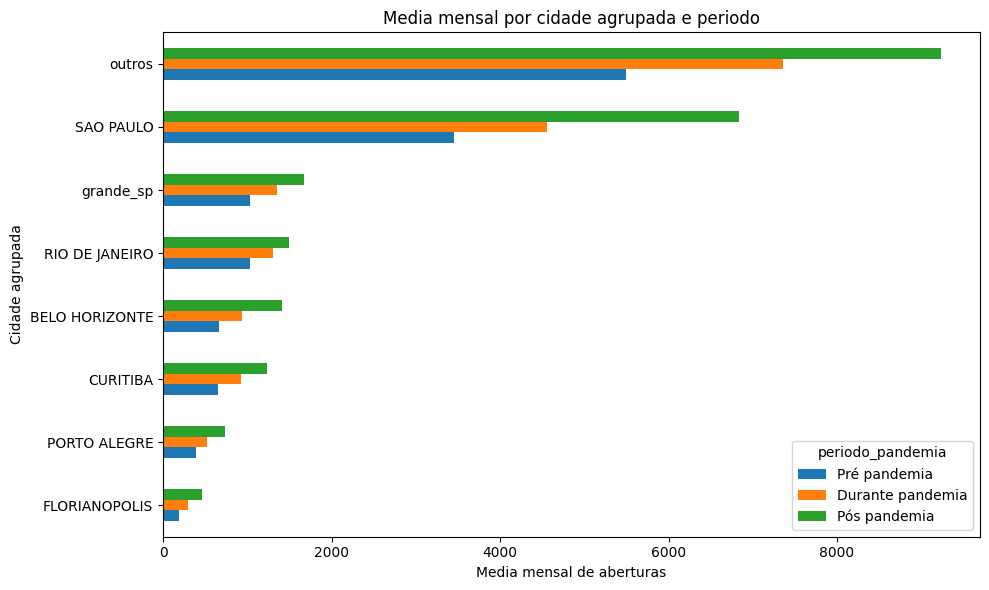

In [7]:
cidades_mensal_periodo = (
df
.groupby(["cidade_agrupada", "ano", "mes", "periodo_pandemia"], as_index = False)["abertura_empresas"]
.sum()
)

media_cidades_periodo = (
cidades_mensal_periodo
.groupby(["cidade_agrupada", "periodo_pandemia"], as_index = False)["abertura_empresas"]
.mean()
.rename(columns = {"abertura_empresas" : "media_mensal_aberturas"})
)

grafico_cidades_periodo = (
media_cidades_periodo
.pivot(index = "cidade_agrupada", columns = "periodo_pandemia", values = "media_mensal_aberturas")
.fillna(0)
)

grafico_cidades_periodo = grafico_cidades_periodo[ordem_periodos]
grafico_cidades_periodo = grafico_cidades_periodo.sort_values(periodo_pos)

grafico_cidades_periodo.plot(kind = "barh", figsize = (10, 6))
plt.title("Media mensal por cidade agrupada e periodo")
plt.xlabel("Media mensal de aberturas")
plt.ylabel("Cidade agrupada")
plt.tight_layout()
plt.show()


## Participacao por cidade

Aqui mostro a fatia de cada cidade agrupada no total de aberturas. Para visualizar concentracao regional.


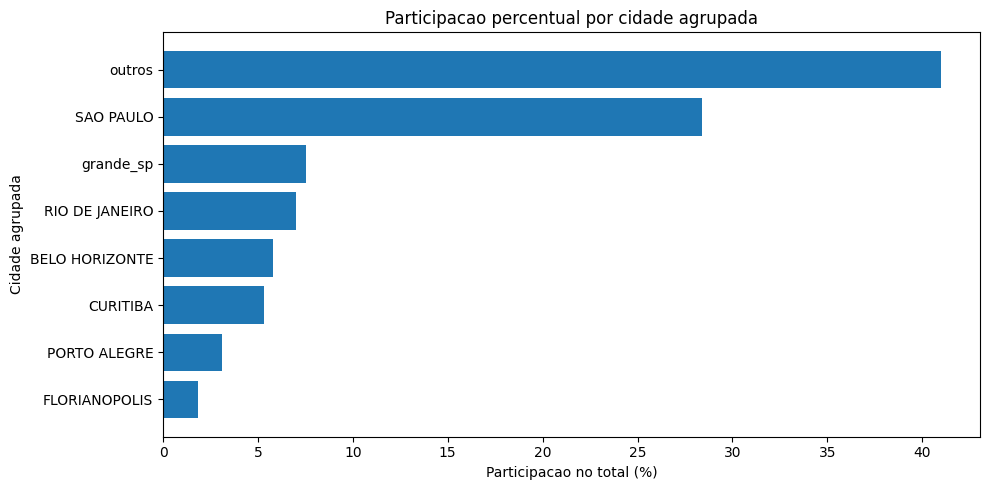

In [8]:
participacao_cidade = (
df
.groupby("cidade_agrupada", as_index = False)["abertura_empresas"]
.sum()
)

participacao_cidade["participacao_percentual"] = (
    participacao_cidade["abertura_empresas"] / participacao_cidade["abertura_empresas"].sum() * 100
)

participacao_cidade = participacao_cidade.sort_values("participacao_percentual")

plt.figure(figsize = (10, 5))
plt.barh(participacao_cidade["cidade_agrupada"], participacao_cidade["participacao_percentual"])
plt.title("Participacao percentual por cidade agrupada")
plt.xlabel("Participacao no total (%)")
plt.ylabel("Cidade agrupada")
plt.tight_layout()
plt.show()


## Participacao por segmento

Este grafico mostra quais segmentos tem maior participacao.


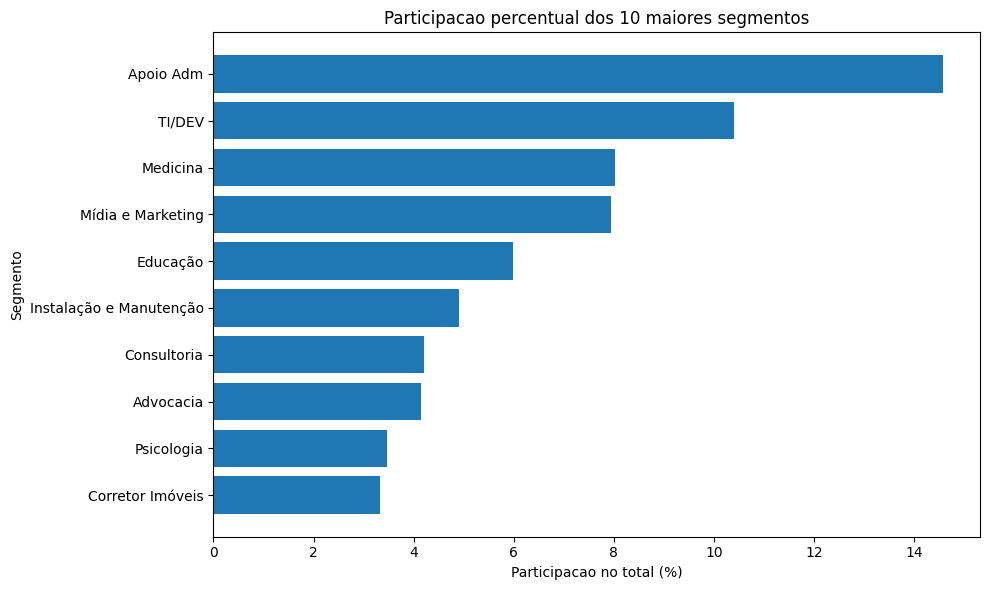

In [9]:
participacao_segmento = (
df
.groupby("class_segmentos", as_index = False)["abertura_empresas"]
.sum()
)

participacao_segmento["participacao_percentual"] = (
    participacao_segmento["abertura_empresas"] / participacao_segmento["abertura_empresas"].sum() * 100
)

participacao_segmento_top10 = participacao_segmento.sort_values("participacao_percentual", ascending = False).head(10)
participacao_segmento_top10 = participacao_segmento_top10.sort_values("participacao_percentual")

plt.figure(figsize = (10, 6))
plt.barh(participacao_segmento_top10["class_segmentos"], participacao_segmento_top10["participacao_percentual"])
plt.title("Participacao percentual dos 10 maiores segmentos")
plt.xlabel("Participacao no total (%)")
plt.ylabel("Segmento")
plt.tight_layout()
plt.show()


## Volatilidade por cidade

A volatilidade ajuda a identificar quais cidades tem comportamento mensal mais instavel.


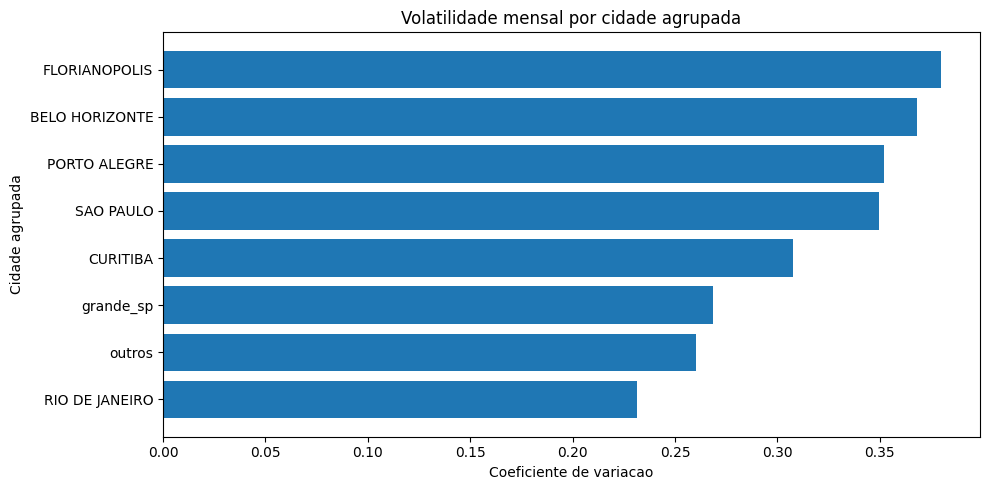

In [10]:
cidades_mensal = (
df
.groupby(["cidade_agrupada", "ano", "mes"], as_index = False)["abertura_empresas"]
.sum()
)

volatilidade_cidade = (
cidades_mensal
.groupby("cidade_agrupada")["abertura_empresas"]
.agg(["mean", "std", "sum", "count"])
.rename(columns = {
    "mean" : "media_mensal",
    "std" : "desvio_padrao",
    "sum" : "total_aberturas",
    "count" : "quantidade_meses"
})
)

volatilidade_cidade["coeficiente_variacao"] = (
    volatilidade_cidade["desvio_padrao"] / volatilidade_cidade["media_mensal"]
)

volatilidade_cidade = volatilidade_cidade.sort_values("coeficiente_variacao")

plt.figure(figsize = (10, 5))
plt.barh(volatilidade_cidade.index, volatilidade_cidade["coeficiente_variacao"])
plt.title("Volatilidade mensal por cidade agrupada")
plt.xlabel("Coeficiente de variacao")
plt.ylabel("Cidade agrupada")
plt.tight_layout()
plt.show()


## Volatilidade por segmento

Tambem olhei a volatilidade por segmento para entender quais tipos de empresa variam mais de um mes para o outro.


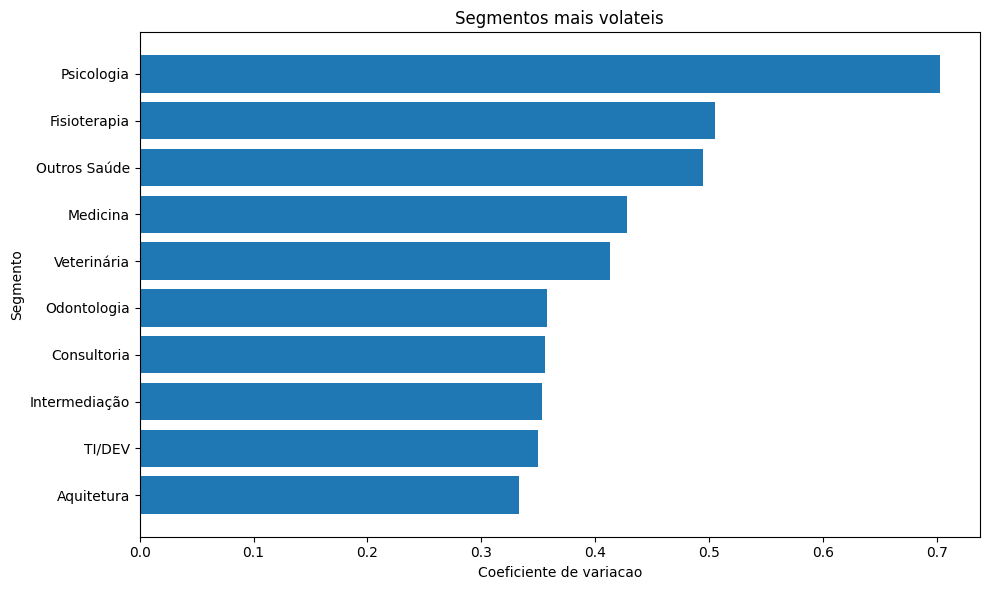

In [11]:
segmentos_mensal = (
df
.groupby(["class_segmentos", "ano", "mes"], as_index = False)["abertura_empresas"]
.sum()
)

volatilidade_segmento = (
segmentos_mensal
.groupby("class_segmentos")["abertura_empresas"]
.agg(["mean", "std", "sum", "count"])
.rename(columns = {
    "mean" : "media_mensal",
    "std" : "desvio_padrao",
    "sum" : "total_aberturas",
    "count" : "quantidade_meses"
})
)

volatilidade_segmento["coeficiente_variacao"] = (
    volatilidade_segmento["desvio_padrao"] / volatilidade_segmento["media_mensal"]
)

volatilidade_segmento = volatilidade_segmento[volatilidade_segmento["total_aberturas"] >= 5000]
volatilidade_segmento = volatilidade_segmento.sort_values("coeficiente_variacao", ascending = False).head(10)
volatilidade_segmento = volatilidade_segmento.sort_values("coeficiente_variacao")

plt.figure(figsize = (10, 6))
plt.barh(volatilidade_segmento.index, volatilidade_segmento["coeficiente_variacao"])
plt.title("Segmentos mais volateis")
plt.xlabel("Coeficiente de variacao")
plt.ylabel("Segmento")
plt.tight_layout()
plt.show()
